In [88]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_groq import ChatGroq
from pydantic import Field,BaseModel

In [89]:
class SentimentState(BaseModel):
    sentiment :Literal["negative","positive"]=Field(description="Sentiment of the review")

In [90]:
model = ChatGroq(model="qwen/qwen3.6-27b",temperature=0)

In [91]:
str_model = model.with_structured_output(SentimentState)

In [92]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [93]:
str_model2=model.with_structured_output(DiagnosisSchema)

In [94]:
response = str_model.invoke("the software was too bad")

In [95]:
class SentimentState(TypedDict):
    review : str
    sentiment : str
    diagnosis : str
    response : str

In [96]:
graph=StateGraph(SentimentState)

In [97]:
def check_sentiment(state: SentimentState)->Literal["positive_response","run_diagnosis"]:
    sentiment = state['sentiment']
    
    if sentiment == 'positive':
        return 'positive_response'
    else: 
        return 'run_diagnosis'

In [98]:
def find_sentiment(state: SentimentState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = str_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: SentimentState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: SentimentState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: SentimentState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
    """
    response = str_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: SentimentState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response = model.invoke(prompt).content
    return {'response': response}

In [99]:
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("positive_response",positive_response)

graph.add_node("negative_response",negative_response)

graph.add_node("run_diagnosis",run_diagnosis)


graph.add_edge(START,'find_sentiment')

graph.add_conditional_edges('find_sentiment',check_sentiment)

graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)


In [100]:
workflow = graph.compile()

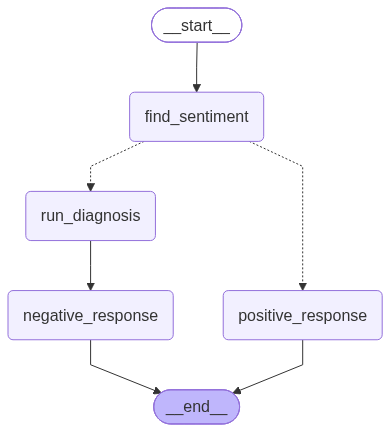

In [101]:
workflow

In [102]:
initial_state = {
    'review' : "The movie was extremely bad thorughtout, but i loved the ending"
}

final_state = workflow.invoke(initial_state)

In [103]:
final_state

{'review': 'The movie was extremely bad thorughtout, but i loved the ending',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Other',
  'tone': 'disappointed',
  'urgency': 'low'},
 'response': '\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - **Role:** Support assistant\n   - **Issue Type:** \'Other\' (unspecified/general)\n   - **User Emotion/Tone:** \'disappointed\'\n   - **Urgency:** \'low\'\n   - **Task:** Write an empathetic, helpful resolution message\n\n2.  **Identify Key Requirements:**\n   - Acknowledge the disappointment empathetically\n   - Address the \'Other\' issue type (keep it open/general but offer concrete next steps)\n   - Match the low urgency (no need for panic language, but still show care and willingness to help)\n   - Provide a clear, helpful resolution path\n   - Maintain a professional, supportive tone\n\n3.  **Determine Message Structure:**\n   - Greeting\n   - Acknowledge emotion & issue\n   - Express empathy & validate fe